<a href="https://colab.research.google.com/github/haris444/autonomous-agents/blob/dev/train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SAC Multi-Agent Training on Colab

Trains 8 agents with Discrete SAC using the shared-trunk architecture.
Agents learn food-foraging, cooperation, combat, and social discrimination through a 12-phase curriculum.

**Runtime:** ~2-4 hours on T4 GPU for full curriculum (20M timesteps)

## 1. Setup

In [1]:
# Clone repo and install deps
!git clone -b dev https://github.com/haris444/autonomous-agents.git
%cd autonomous-agents
!pip install -q pyyaml

Cloning into 'autonomous-agents'...
remote: Enumerating objects: 233, done.
remote: Counting objects: 100% (233/233), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 233 (delta 137), reused 233 (delta 137), pack-reused 0 (from 0)
Receiving objects: 100% (233/233), 1.29 MiB | 25.43 MiB/s, done.
Resolving deltas: 100% (137/137), done.
/content/autonomous-agents


In [2]:
import torch
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

CUDA: True
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Configure Training

Two options:
- **Full curriculum** (recommended): Agents progress through 12 phases, from solo food-finding to multi-agent social dynamics
- **Free-play**: Skip curriculum, all 8 agents active from the start with predators

In [ ]:
import yaml, os
os.makedirs(OUTPUT_DIR, exist_ok=True)

config = {
    'experiment': {
        'name': f'sac_{MODE}_colab',
        'description': f'SAC {MODE} training on Colab GPU',
    },
    # Environment
    'grid_size': 15,
    'n_agents': 8,
    'max_hp': 100.0,
    'hp_decay_rate': 0.01,
    'attack_damage_fraction': 0.125,
    'lifesteal_fraction': 0.25,
    'max_steps_per_episode': 128,
    # Entity tokens
    'max_food_tokens': 16,
    'fourier_bands': 4,
    'attention_embed_dim': 64,
    'attention_num_heads': 4,
    'group_embed_dim': 16,
    # Food
    'poor_food_value': 10.0,
    'rich_food_value': 30.0,
    'poor_food_spawn_rate': 0.000336,
    'rich_food_spawn_rate': 0.0084,
    'food_coverage_cap': 0.40,
    # Rewards
    'r_small': 10.0,
    'r_large': 20.0,
    'r_attack_mult': 0.1,
    'r_damage_taken': -1.0,
    'r_low_hp': 0.0,
    'r_food_share': 1.0,
    'r_betrayal': -2.0,
    'r_reciprocity': 0.5,
    'r_defense': 1.0,
    'r_revenge': 0.5,
    'r_survival': 0.0,
    'r_death': 0.0,
    'r_coop_attempt': 2.0,
    'r_approach_food': 0.1,
    'r_ally_proximity': 0.0,
    # Social hierarchy
    'r_hierarchy': 0.25,
    'hierarchy_food_weight': 1.0,
    'hierarchy_damage_weight': 1.0,
    'hierarchy_hp_weight': 1.0,
    'hierarchy_kill_weight': 2.0,
    # SAC hyperparameters (from sac_phase11_enemy_kill_status_2 + UTD)
    'sac_learning_rate': 3e-4,
    'sac_tau': 0.005,
    'sac_alpha_init': 0.8,
    'sac_auto_alpha': True,
    'sac_target_entropy_scale': 0.1,
    'sac_gamma': 0.9,
    'sac_buffer_size': 500_000,
    'sac_batch_size': 2048,
    'sac_learning_starts': 50_000,
    'sac_update_frequency': 1,
    'sac_utd_ratio': 4,
    'sac_target_update_interval': 1,
    # Training
    'total_timesteps': TOTAL_TIMESTEPS,
    'seed': 42,
    'n_envs': N_ENVS,
    # Predator
    'n_predators': 1,
    'predator_hp_mult': 0.5,
    'predator_damage': 10.0,
    'predator_kill_reward': 5.0,
    'predator_respawn_steps': 20,
    # Training config
    'training': {
        'output_dir': OUTPUT_DIR,
    },
}

if MODE == 'curriculum':
    config['pretrain_mode'] = True
    config['curriculum_enabled'] = True
else:
    config['pretrain_mode'] = False
    config['curriculum_enabled'] = False

config_path = f'{OUTPUT_DIR}/config.yaml'
with open(config_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)
print(f'Config written to {config_path}')
print(f'Mode: {MODE} | Timesteps: {TOTAL_TIMESTEPS:,} | Envs: {N_ENVS}')
print(f'UTD ratio: {config["sac_utd_ratio"]} | Batch size: {config["sac_batch_size"]}')
print(f'SAC: alpha_init={config["sac_alpha_init"]}, entropy_scale={config["sac_target_entropy_scale"]}, gamma={config["sac_gamma"]}, warmup={config["sac_learning_starts"]}')

In [12]:
import yaml, os
os.makedirs(OUTPUT_DIR, exist_ok=True)

config = {
    'experiment': {
        'name': f'sac_{MODE}_colab',
        'description': f'SAC {MODE} training on Colab GPU',
    },
    # Environment
    'grid_size': 15,
    'n_agents': 8,
    'max_hp': 100.0,
    'hp_decay_rate': 0.01,
    'attack_damage_fraction': 0.125,
    'lifesteal_fraction': 0.25,
    'max_steps_per_episode': 128,
    # Entity tokens
    'max_food_tokens': 16,
    'fourier_bands': 4,
    'attention_embed_dim': 64,
    'attention_num_heads': 4,
    'group_embed_dim': 16,
    # Food
    'poor_food_value': 10.0,
    'rich_food_value': 30.0,
    'poor_food_spawn_rate': 0.000336,
    'rich_food_spawn_rate': 0.0084,
    'food_coverage_cap': 0.40,
    # Rewards
    'r_small': 10.0,
    'r_large': 20.0,
    'r_attack_mult': 0.1,
    'r_damage_taken': -1.0,
    'r_low_hp': 0.0,
    'r_food_share': 1.0,
    'r_betrayal': -2.0,
    'r_reciprocity': 0.5,
    'r_defense': 1.0,
    'r_revenge': 0.5,
    'r_survival': 0.0,
    'r_death': 0.0,
    'r_coop_attempt': 2.0,
    'r_approach_food': 0.1,
    'r_ally_proximity': 0.0,
    # Social hierarchy
    'r_hierarchy': 0.25,
    'hierarchy_food_weight': 1.0,
    'hierarchy_damage_weight': 1.0,
    'hierarchy_hp_weight': 1.0,
    'hierarchy_kill_weight': 2.0,
    # SAC hyperparameters
    'sac_learning_rate': 3e-4,
    'sac_tau': 0.005,
    'sac_alpha_init': 0.5,
    'sac_auto_alpha': True,
    'sac_target_entropy_scale': 0.7,
    'sac_gamma': 0.9,
    'sac_buffer_size': 500_000,
    'sac_batch_size': 1024,
    'sac_learning_starts': 100_000,
    'sac_update_frequency': 1,
    'sac_target_update_interval': 1,
    # Training
    'total_timesteps': TOTAL_TIMESTEPS,
    'seed': 42,
    'n_envs': N_ENVS,
    # Predator
    'n_predators': 1,
    'predator_hp_mult': 0.5,
    'predator_damage': 10.0,
    'predator_kill_reward': 5.0,
    'predator_respawn_steps': 20,
    # Training config
    'training': {
        'output_dir': OUTPUT_DIR,
    },
}

if MODE == 'curriculum':
    config['pretrain_mode'] = True
    config['curriculum_enabled'] = True
else:
    config['pretrain_mode'] = False
    config['curriculum_enabled'] = False

config_path = f'{OUTPUT_DIR}/config.yaml'
with open(config_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)
print(f'Config written to {config_path}')
print(f'Mode: {MODE} | Timesteps: {TOTAL_TIMESTEPS:,} | Envs: {N_ENVS}')

Config written to results/sac_colab/config.yaml
Mode: curriculum | Timesteps: 20,000,000 | Envs: 16


## 3. Train

In [13]:
!python -m training.train_sac \
    --experiment {config_path} \
    --csv-log {CSV_LOG} \
    --ckpt-every {CHECKPOINT_EVERY} \
    --pretrain

Streaming output truncated to the last 5000 lines.
Step 13,799,680 | Phase 1 (-145/448) | Ep: 65360 | Avg Return: -144.8 | SPS: 2959 | Buffer: 500,000 | Updates: 53866 | Q: -2.77 | a_d: 0.526 a_a: 0.780
Step 13,800,960 | Phase 1 (-145/448) | Ep: 65362 | Avg Return: -145.0 | SPS: 2959 | Buffer: 500,000 | Updates: 53871 | Q: -2.43 | a_d: 0.526 a_a: 0.780
Step 13,802,240 | Phase 1 (-145/448) | Ep: 65372 | Avg Return: -144.6 | SPS: 2959 | Buffer: 500,000 | Updates: 53876 | Q: -2.29 | a_d: 0.526 a_a: 0.780
Step 13,803,520 | Phase 1 (-144/448) | Ep: 65376 | Avg Return: -143.5 | SPS: 2959 | Buffer: 500,000 | Updates: 53881 | Q: -2.18 | a_d: 0.526 a_a: 0.780
Step 13,804,800 | Phase 1 (-145/448) | Ep: 65382 | Avg Return: -145.2 | SPS: 2959 | Buffer: 500,000 | Updates: 53886 | Q: -2.29 | a_d: 0.526 a_a: 0.780
Step 13,806,080 | Phase 1 (-146/448) | Ep: 65392 | Avg Return: -146.5 | SPS: 2959 | Buffer: 500,000 | Updates: 53891 | Q: -1.80 | a_d: 0.526 a_a: 0.780
Step 13,807,360 | Phase 1 (-147/448) 

## 4. Training Curves

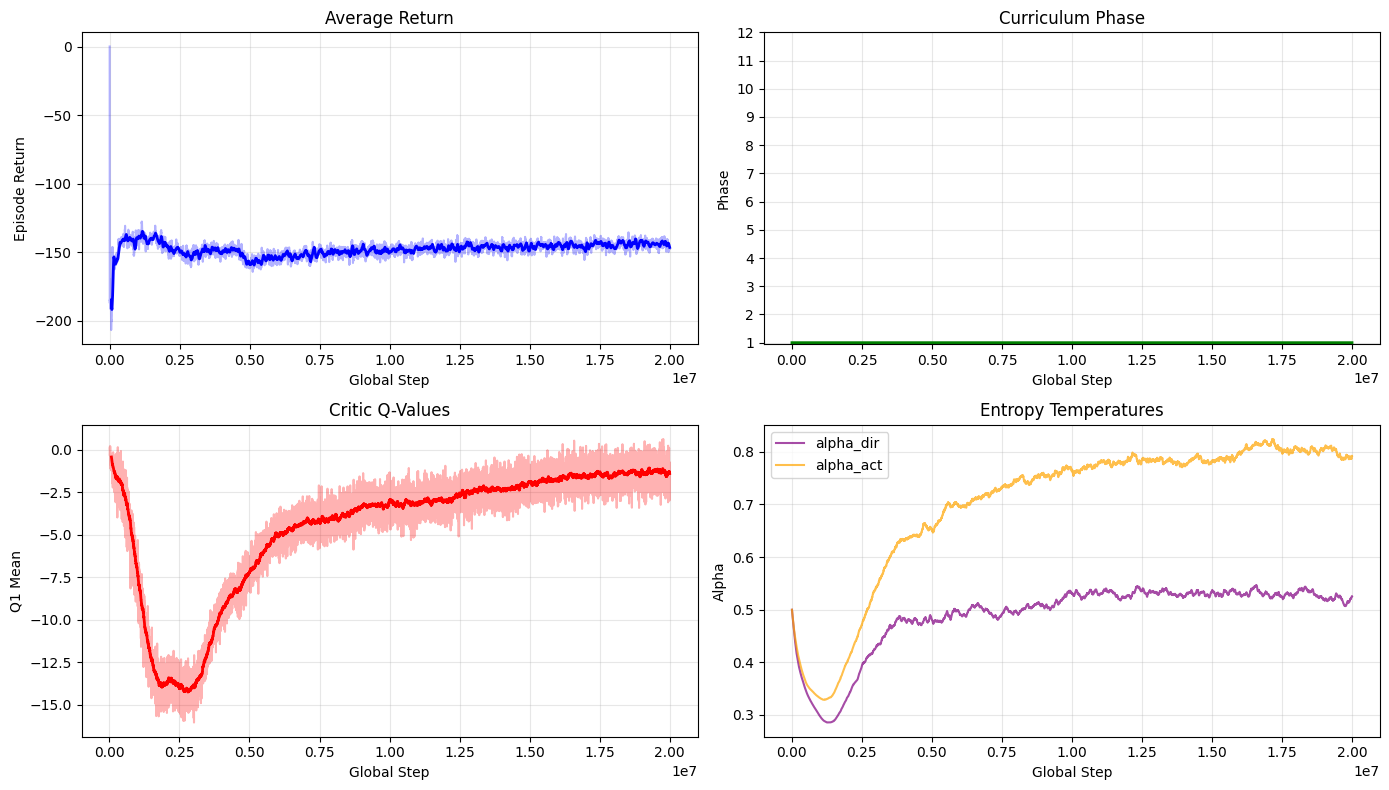

Final return: -147.4
Episodes: 94400
Final phase: 1


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(CSV_LOG)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Episode return
ax = axes[0, 0]
ax.plot(df['global_step'], df['episode_return'], alpha=0.3, color='blue')
ax.plot(df['global_step'], df['episode_return'].rolling(50).mean(), color='blue', linewidth=2)
ax.set_xlabel('Global Step')
ax.set_ylabel('Episode Return')
ax.set_title('Average Return')
ax.grid(True, alpha=0.3)

# Curriculum phase
ax = axes[0, 1]
ax.plot(df['global_step'], df['curriculum_phase'], color='green', linewidth=2)
ax.set_xlabel('Global Step')
ax.set_ylabel('Phase')
ax.set_title('Curriculum Phase')
ax.set_yticks(range(1, 13))
ax.grid(True, alpha=0.3)

# Q-values
ax = axes[1, 0]
q1 = df['q1_mean'].replace(0, float('nan'))
ax.plot(df['global_step'], q1, alpha=0.3, color='red')
ax.plot(df['global_step'], q1.rolling(50).mean(), color='red', linewidth=2)
ax.set_xlabel('Global Step')
ax.set_ylabel('Q1 Mean')
ax.set_title('Critic Q-Values')
ax.grid(True, alpha=0.3)

# Entropy alphas
ax = axes[1, 1]
ad = df['alpha_dir'].replace(0, float('nan'))
aa = df['alpha_act'].replace(0, float('nan'))
ax.plot(df['global_step'], ad, label='alpha_dir', color='purple', alpha=0.7)
ax.plot(df['global_step'], aa, label='alpha_act', color='orange', alpha=0.7)
ax.set_xlabel('Global Step')
ax.set_ylabel('Alpha')
ax.set_title('Entropy Temperatures')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150)
plt.show()
print(f'Final return: {df["episode_return"].iloc[-1]:.1f}')
print(f'Episodes: {df["episodes_completed"].iloc[-1]}')
print(f'Final phase: {df["curriculum_phase"].iloc[-1]}')

## 5. Resume from Checkpoint (optional)

If training was interrupted, resume from the latest checkpoint.

In [ ]:
import glob

checkpoints = sorted(glob.glob(f'{OUTPUT_DIR}/checkpoint_ep*.pt'))
if checkpoints:
    latest = checkpoints[-1]
    print(f'Latest checkpoint: {latest}')
    print(f'To resume, run the cell below.')
else:
    print('No checkpoints found yet.')

In [ ]:
# Uncomment to resume training from latest checkpoint
# !python -m training.train_sac \
#     --experiment {config_path} \
#     --csv-log {CSV_LOG} \
#     --ckpt-every {CHECKPOINT_EVERY} \
#     --pretrain \
#     --checkpoint {latest}

## 6. Save to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
drive_dir = '/content/drive/MyDrive/AutonomousAgents/sac_colab'
os.makedirs(drive_dir, exist_ok=True)

# Copy checkpoints and logs
for f in glob.glob(f'{OUTPUT_DIR}/*'):
    dst = os.path.join(drive_dir, os.path.basename(f))
    shutil.copy2(f, dst)
    print(f'Copied: {os.path.basename(f)}')

print(f'\nAll results saved to: {drive_dir}')